# HTC

**HTC** steht für **Heat Transfer Coefficient**.

Beschreibt:

> **Wie stark eine Oberfläche Wärme mit ihrer Umgebung austauscht.**

# Randbedingug
Beschreibt, was an der Oberfläche eines Körpers thermisch passiert.

## HTC Formel:

$$
htc_{agg} = \frac{q_{summe}}{kontaktflaeche_{summe} \cdot t_{flaechengewichtet}}
$$

mit:
- `q_summe` = aggregierter Wärmestrom
- `kontaktflaeche_summe` = aggregierte Fläche
- `t_flaechengewichtet` = flächengewichtete Temperaturdifferenz

In [1]:
# ============================================================
# Funktion: HTC-Heatup-Vergleich für ein Element
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

datei = Path("../NikosZeug/region_zeit_aggregation.csv")
df = pd.read_csv(datei)

schwelle_t = 1e-4
df_htc = df.copy()

df_htc["htc_agg"] = np.where(
    df_htc["t_flaechengewichtet"] >= schwelle_t,
    df_htc["q_summe"] / (df_htc["kontaktflaeche_summe"] * df_htc["t_flaechengewichtet"]),
    np.nan
)

def zeige_htc_heatup_vergleich(df_htc, element_name, heatup_cases=("Case1", "Case3", "Case5", "Case6", "Case7"), time_min=100):
    
    
    oberflaechen = ["top_surface", "bottom_surface", "lateral", "support"]

    df_element = df_htc[
        (df_htc["element"] == element_name) &
        (df_htc["case"].isin(heatup_cases))
    ].copy()

    df_element_spaet = df_element[df_element["time_s"] >= time_min].copy()

    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.flatten()

    for ax, region in zip(axes, oberflaechen):
        daten_region = df_element_spaet[df_element_spaet["region_group"] == region]

        for case_name in heatup_cases:
            daten_case = daten_region[daten_region["case"] == case_name]
            ax.plot(daten_case["time_s"], daten_case["htc_agg"], label=case_name)

        ax.set_title(region)
        ax.set_xlabel("Zeit [s]")
        ax.set_ylabel("htc_agg [W/m²K]")
        ax.grid(True)
        ax.legend()

    plt.suptitle(f"{element_name}: aggregierter HTC für die Heatup-Cases (ab {time_min} s)", y=1.02)
    plt.tight_layout()
    plt.show()

    # ==========================================
    # 1. Die Steady-State Tabelle (Das Ende der Simulation)
    # ==========================================
    # Wir schneiden das Aufheiz-Chaos der ersten Stunden ab und schauen 
    # nur auf die perfekten, flachen Linien am Ende (ab Sekunde 15.000).
    steady_state_start = 15000 
    
    df_steady_state = df_element[df_element["time_s"] >= steady_state_start].copy()
    
    # Wir berechnen den Mittelwert (mean) nur für diese allerletzte Phase.
    # min, max und median brauchen wir nicht mehr, da die Linie ja ohnehin flach ist.
    summary_cases = (
        df_steady_state
        .groupby(["region_group", "case"])["htc_agg"]
        .agg(["mean"]) 
        .reset_index()
        .rename(columns={"mean": "HTC_SteadyState"})
    )
    
    # ==========================================
    # 2. Die Daumenregel ("Generalize boundary conditions")
    # ==========================================
    # Jetzt erfüllen wir den Zeiss-Auftrag: "apply ONE boundary condition for all settings"
    # Wir nehmen die HTC-Werte aus Case 1, 3 und 5 und bilden daraus EINEN finalen Durchschnitt.
    zeiss_daumenregel = (
        summary_cases
        .groupby("region_group")["HTC_SteadyState"]
        .agg(["mean"])
        .reset_index()
        .rename(columns={"mean": "Generalisierter_HTC_Zeiss"})
    )

    # Wir geben beide Tabellen zurück, damit du sie dir ausdrucken/anzeigen lassen kannst
    return summary_cases, zeiss_daumenregel

# =========================================================
# Funktion: HTC-Cooldown-Vergleich (Abkühlphase)
# =========================================================
def zeige_htc_cooldown_vergleich(df_htc, element_name, cooldown_cases=("Case2", "Case4"), time_min=100):
    import matplotlib.pyplot as plt
    
    oberflaechen = ["top_surface", "bottom_surface", "lateral", "support"]
    
    df_element = df_htc[
        (df_htc["element"] == element_name) & 
        (df_htc["case"].isin(cooldown_cases))
    ].copy()
    
    df_element_spaet = df_element[df_element["time_s"] >= time_min].copy()
    
    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.flatten()
    
    for ax, region in zip(axes, oberflaechen):
        daten_region = df_element_spaet[df_element_spaet["region_group"] == region]
        
        for case_name in cooldown_cases:
            daten_case = daten_region[daten_region["case"] == case_name]
            ax.plot(daten_case["time_s"], daten_case["htc_agg"], label=case_name)
            
        ax.set_title(region)
        ax.set_xlabel("Zeit [s]")
        ax.set_ylabel("HTC_agg [W/m²K]")
        ax.grid(True)
        ax.legend()
        
    plt.suptitle(f"{element_name}: Aggregierter HTC für die Cooldown-Cases (ab {time_min} s)", y=1.02, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ==========================================
    # Tabellen-Berechnung (Steady State)
    # ==========================================
    steady_state_start = 15000 
    df_steady_state = df_element[df_element["time_s"] >= steady_state_start].copy()
    
    summary_cases = (
        df_steady_state
        .groupby(["region_group", "case"])["htc_agg"]
        .agg(["mean"]) 
        .reset_index()
        .rename(columns={"mean": "HTC_SteadyState"})
    )
    
    zeiss_daumenregel_cooldown = (
        summary_cases
        .groupby("region_group")["HTC_SteadyState"]
        .agg(["mean"])
        .reset_index()
        .rename(columns={"mean": "Generalisierter_HTC_Cooldown"})
    )
    
    return summary_cases, zeiss_daumenregel_cooldown

# =========================================================
# AUSFÜHRUNG: Hier rufen wir die Funktion auf!
# =========================================================
# Um das auszuführen, schreibe einfach ganz unten in dein Skript:
# summary_cool, daumenregel_cool = zeige_htc_cooldown_vergleich(df_htc, "Element3")
# print(daumenregel_cool)

# HTC pro Fläche pro Case (Heat Up)

--- HEATUP PHASE: Element1 ---


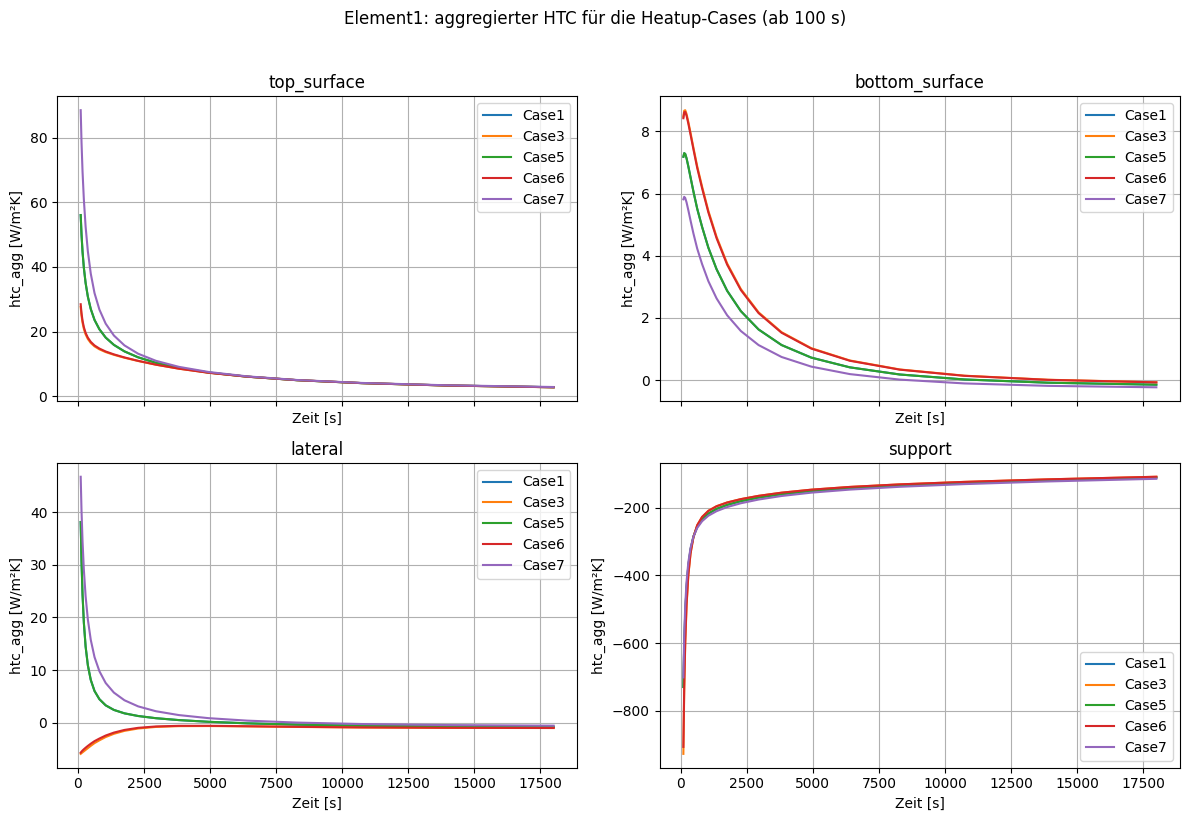

      region_group   case  HTC_SteadyState
0   bottom_surface  Case1        -0.150000
1   bottom_surface  Case3        -0.072863
2   bottom_surface  Case5        -0.150000
3   bottom_surface  Case6        -0.075654
4   bottom_surface  Case7        -0.233912
5          lateral  Case1        -0.736306
6          lateral  Case3        -0.963924
7          lateral  Case5        -0.736306
8          lateral  Case6        -0.952140
9          lateral  Case7        -0.517092
10         support  Case1      -111.228041
11         support  Case3      -108.877140
12         support  Case5      -111.228041
13         support  Case6      -108.828613
14         support  Case7      -114.833853
15     top_surface  Case1         2.810395
16     top_surface  Case3         2.796183
17     top_surface  Case5         2.810395
18     top_surface  Case6         2.791587
19     top_surface  Case7         2.878240
     region_group  Generalisierter_HTC_Zeiss
0  bottom_surface                  -0.136486
1      

In [2]:
# === ANALYSE FÜR LINSE 1 ===
element_name = "Element1"

print(f"--- HEATUP PHASE: {element_name} ---")
summary_heat, daumenregel_heat = zeige_htc_heatup_vergleich(df_htc, element_name)
print(summary_heat)
print(daumenregel_heat)



# HTC pro Fläche pro Case (Cooldown)

--- COOLDOWN PHASE: Element1 ---


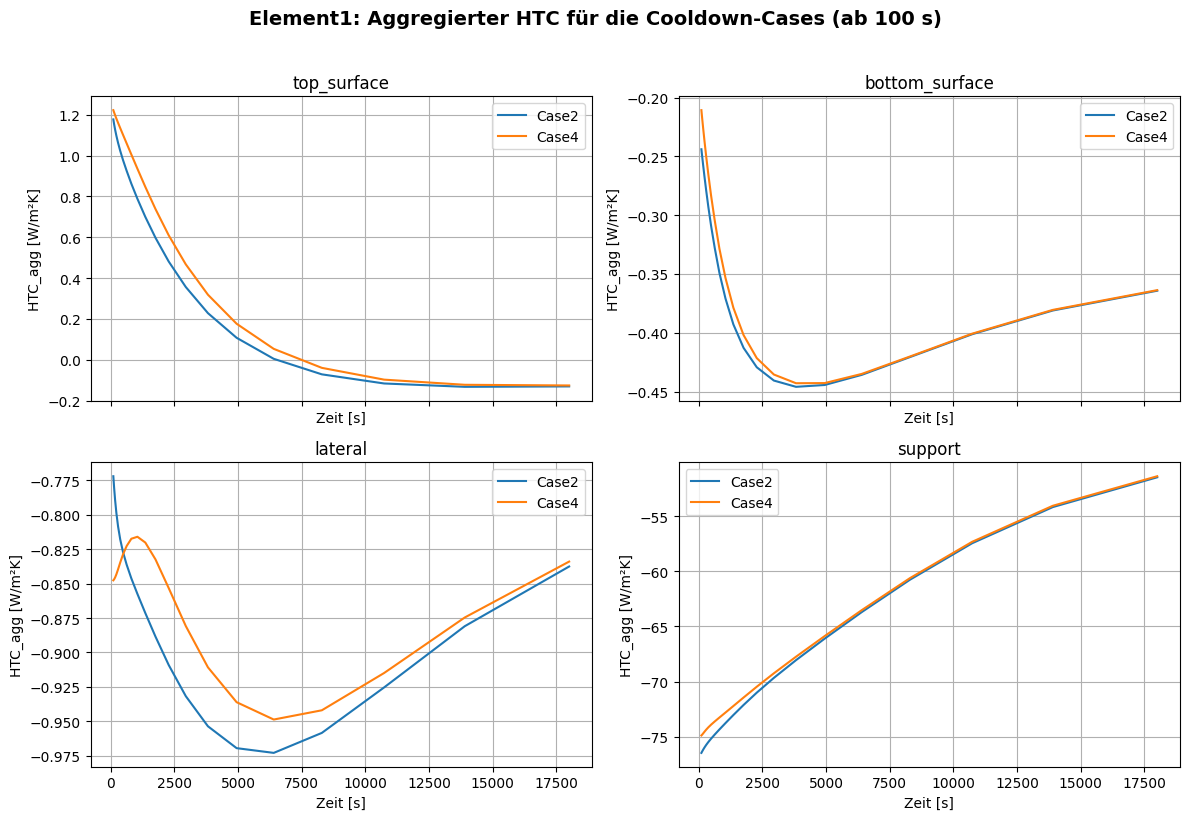

     region_group   case  HTC_SteadyState
0  bottom_surface  Case2        -0.364239
1  bottom_surface  Case4        -0.363754
2         lateral  Case2        -0.837641
3         lateral  Case4        -0.834070
4         support  Case2       -51.466224
5         support  Case4       -51.371169
6     top_surface  Case2        -0.130916
7     top_surface  Case4        -0.126302
     region_group  Generalisierter_HTC_Cooldown
0  bottom_surface                     -0.363996
1         lateral                     -0.835856
2         support                    -51.418696
3     top_surface                     -0.128609


In [3]:


print(f"--- COOLDOWN PHASE: {element_name} ---")
summary_cool, daumenregel_cool = zeige_htc_cooldown_vergleich(df_htc, element_name)
print(summary_cool)
print(daumenregel_cool)

# Curve Fitting (vor 15000s)

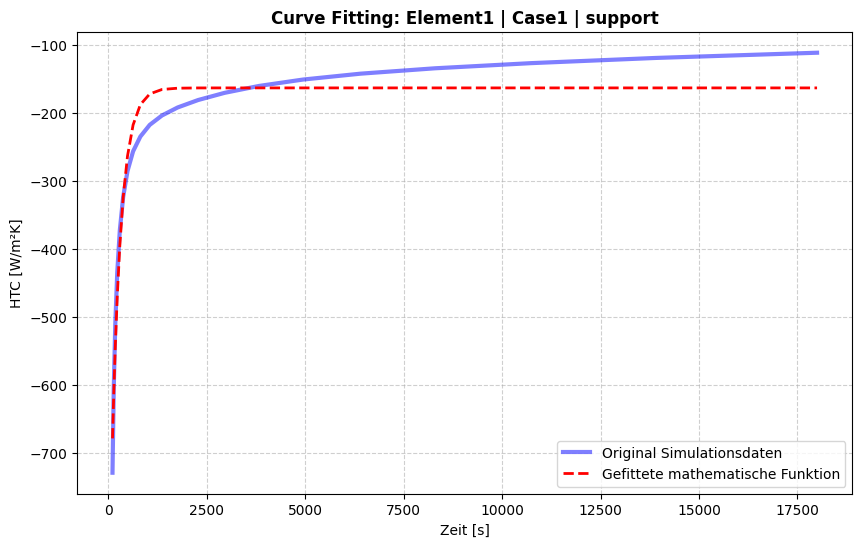

DIE FINALE FUNKTION FÜR ZEISS:
h(t) = -800.21 * e^(-0.00430 * t) -163.04
------------------------------------------------------------
Bedeutung:
- Der Parameter 'c' (-163.04) ist unser Steady-State Wert!
- Wenn die Ingenieure diese Formel in Python oder Excel tippen,
  können sie den HTC für jede beliebige Sekunde 't' berechnen.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================================================
# 1. Daten vorbereiten (Linse 1, Case 1, Support)
# =========================================================
element_name = "Element1"
case_name = "Case1"
region_name = "support"

# Wir filtern die Daten (ab 100s, um die Start-Spikes zu ignorieren)
df_fit = df_htc[
    (df_htc["element"] == element_name) & 
    (df_htc["case"] == case_name) & 
    (df_htc["region_group"] == region_name) &
    (df_htc["time_s"] >= 100)
].copy()

# X- und Y-Achse für das Fitting
t_data = df_fit["time_s"].values
h_data = df_fit["htc_agg"].values

# =========================================================
# 2. Die mathematische Funktion definieren
# =========================================================
def exponential_funktion(t, a, b, c):
    return a * np.exp(-b * t) + c

# =========================================================
# 3. Curve Fitting anwenden (Die Magie von SciPy)
# =========================================================
# p0 sind unsere "Start-Schätzwerte" für a, b und c, damit SciPy schneller rechnet.
# Für c nehmen wir euren gefundenen Steady-State Wert (ca. -190)
start_schaetzung = [-1000, 0.001, -190] 

# curve_fit sucht nun die optimalen Parameter
optimale_parameter, covariance = curve_fit(exponential_funktion, t_data, h_data, p0=start_schaetzung)

a_opt, b_opt, c_opt = optimale_parameter

# Wir berechnen die Y-Werte unserer neuen, perfekten Formel
h_fit = exponential_funktion(t_data, a_opt, b_opt, c_opt)

# =========================================================
# 4. Ergebnisse visualisieren & ausdrucken
# =========================================================
plt.figure(figsize=(10, 6))
plt.plot(t_data, h_data, label="Original Simulationsdaten", color="blue", linewidth=3, alpha=0.5)
plt.plot(t_data, h_fit, label="Gefittete mathematische Funktion", color="red", linestyle="--", linewidth=2)

plt.title(f"Curve Fitting: {element_name} | {case_name} | {region_name}", fontweight="bold")
plt.xlabel("Zeit [s]")
plt.ylabel("HTC [W/m²K]")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

print("="*60)
print(f"DIE FINALE FUNKTION FÜR ZEISS:")
print("="*60)
print(f"h(t) = {a_opt:.2f} * e^(-{b_opt:.5f} * t) {c_opt:+.2f}")
print("-" * 60)
print(f"Bedeutung:")
print(f"- Der Parameter 'c' ({c_opt:.2f}) ist unser Steady-State Wert!")
print(f"- Wenn die Ingenieure diese Formel in Python oder Excel tippen,")
print(f"  können sie den HTC für jede beliebige Sekunde 't' berechnen.")
print("="*60)

# Doppelte genauere Exponentialfunktion

In [5]:
# ==============================================================================
# STARTWERT-CHEAT-SHEET FÜR DOPPEL-EXPONENTIAL CURVE FITTING
# Format: [a1 (schnell), b1 (schnell), a2 (langsam), b2 (langsam), c (Steady State)]
# Regel: a1 + a2 + c = Ungefährer Startwert bei t=0
# ==============================================================================

# --- 1. AUFHEIZPHASE (Heatup: Case 1, 3, 5) ---
startwerte_heatup = {
    # Startet sehr hoch (ca. 55), fällt dann steil ab auf ca. +2.8
    "top_surface":    [40, 0.01, 12, 0.0001, 2.8],
    
    # Startet extrem tief im Minus (ca. -800), steigt auf ca. -110 (bzw. -193 bei Element 3)
    "support":        [-500, 0.01, -200, 0.0001, -110], 
    
    # Startet bei ca. +38, fällt ab auf ca. -0.8
    "lateral":        [30, 0.01, 8, 0.0001, -0.8],
    
    # Startet bei ca. +9, fällt ab auf ca. -0.1
    "bottom_surface": [7, 0.01, 2, 0.0001, -0.1]
}

# --- 2. ABKÜHLPHASE (Cooldown: Case 2, 4) ---
startwerte_cooldown = {
    # Startet bei ca. +1.2, fällt ab auf ca. -0.12
    "top_surface":    [1.0, 0.01, 0.3, 0.0001, -0.12],
    
    # Startet bei ca. -75, steigt langsam auf ca. -51
    "support":        [-20, 0.01, -4, 0.0001, -51.0],
    
    # Ziemlich flach, startet bei -0.75, endet bei -0.83
    "lateral":        [0.05, 0.01, 0.03, 0.0001, -0.83],
    
    # Startet bei ca. -0.2, fällt auf ca. -0.36
    "bottom_surface": [0.1, 0.01, 0.06, 0.0001, -0.36]
}

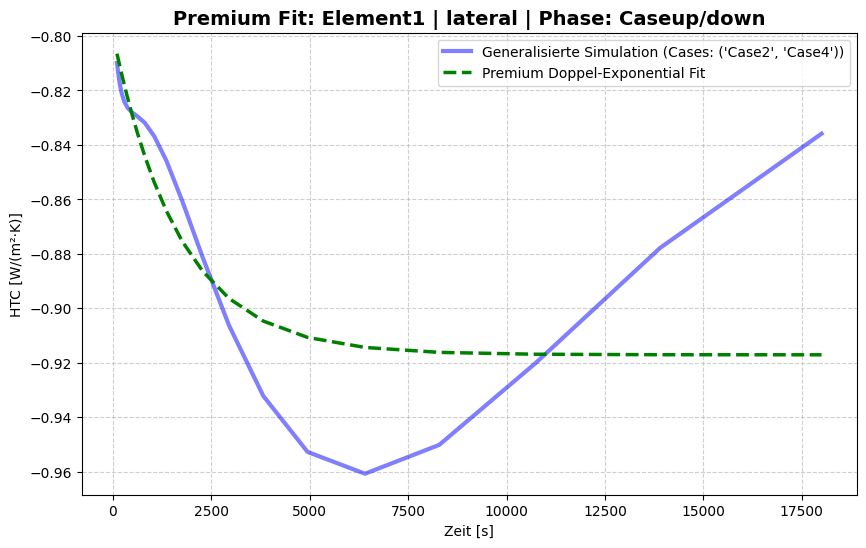

DIE FINALE GENERALISIERTE FUNKTION FÜR ZEISS (Element1 - lateral):
h(t) = 0.07 * e^(-0.00059 * t) +0.04 * e^(-0.00059 * t) -0.92
--------------------------------------------------------------------------------
Bedeutung:
- Der Parameter 'c' (-0.92) ist der finale Steady-State (TCC)!
- Diese eine Formel ersetzt alle 2 Laser-Settings für diese Fläche.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================================================
# 1. Die Premium-Formel definieren
# =========================================================
def doppel_exponential(t, a1, b1, a2, b2, c):
    # a1, b1: Für die schnelle Aufheizphase (Oberfläche)
    # a2, b2: Für das langsame Kriechen (Glaskern)
    # c: Unser geliebter Steady-State!
    return a1 * np.exp(-b1 * t) + a2 * np.exp(-b2 * t) + c

# =========================================================
# 2. Die Hauptfunktion für euer Notebook
# =========================================================
def zeige_premium_curve_fit(df_htc, element_name, region_name, cases, start_schaetzung):
    
    # A) Daten filtern (nur ab 100s, um Start-Spikes auszublenden)
    df_fit = df_htc[
        (df_htc["element"] == element_name) & 
        (df_htc["case"].isin(cases)) & 
        (df_htc["region_group"] == region_name) &
        (df_htc["time_s"] >= 100)
    ].copy()
    
    # B) DER GENERALISIERUNGS-TRICK: 
    # Wir gruppieren nach der Zeit und bilden den Durchschnitt.
    # Das verschmilzt Case 1, 3 und 5 zu einer perfekten Linie!
    df_generalized = df_fit.groupby("time_s")["htc_agg"].mean().reset_index()
    
    t_data = df_generalized["time_s"].values
    h_data = df_generalized["htc_agg"].values
    
    # C) Curve Fitting anwenden
    # maxfev=10000 gibt dem PC mehr Zeit für diese komplexe Formel
    opt_params, _ = curve_fit(doppel_exponential, t_data, h_data, p0=start_schaetzung, maxfev=10000)
    a1_opt, b1_opt, a2_opt, b2_opt, c_opt = opt_params
    
    # D) Die Y-Werte für unsere fertige Formel berechnen
    h_fit = doppel_exponential(t_data, a1_opt, b1_opt, a2_opt, b2_opt, c_opt)
    
    # E) Das Diagramm zeichnen
    plt.figure(figsize=(10, 6))
    plt.plot(t_data, h_data, label=f"Generalisierte Simulation (Cases: {cases})", color="blue", linewidth=3, alpha=0.5)
    plt.plot(t_data, h_fit, label="Premium Doppel-Exponential Fit", color="green", linestyle="--", linewidth=2.5)
    
    plt.title(f"Premium Fit: {element_name} | {region_name} | Phase: {cases[0][:4]}up/down", fontweight="bold", fontsize=14)
    plt.xlabel("Zeit [s]")
    plt.ylabel("HTC [W/(m²·K)]")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()
    
    # F) Formel für Zeiss ausdrucken
    print("="*80)
    print(f"DIE FINALE GENERALISIERTE FUNKTION FÜR ZEISS ({element_name} - {region_name}):")
    print("="*80)
    print(f"h(t) = {a1_opt:.2f} * e^(-{b1_opt:.5f} * t) {a2_opt:+.2f} * e^(-{b2_opt:.5f} * t) {c_opt:+.2f}")
    print("-" * 80)
    print(f"Bedeutung:")
    print(f"- Der Parameter 'c' ({c_opt:.2f}) ist der finale Steady-State (TCC)!")
    print(f"- Diese eine Formel ersetzt alle {len(cases)} Laser-Settings für diese Fläche.")
    print("="*80)



zeige_premium_curve_fit(
    df_htc=df_htc, 
    element_name="Element1", 
    region_name="lateral", 
    cases=("Case2", "Case4"), 
    start_schaetzung=startwerte_cooldown["lateral"]
)
# oder startwerte_cooldown


# Berechne MAE/MSE

FEHLER DER GENERALISIERTEN FUNKTION
Element1 | lateral | Cases: ('Case2', 'Case4')
MSE  = 0.000729
MAE  = 0.018580
RMSE = 0.027008
--------------------------------------------------------------------------------
h(t) = 0.073031 * e^(-0.00058896 * t) +0.044382 * e^(-0.00058897 * t) -0.917064

FEHLER PRO EINZELNEM CASE:
    case       MSE       MAE      RMSE  Anzahl_Werte
0  Case2  0.001118  0.025310  0.033440            21
1  Case4  0.001165  0.028993  0.034126            21


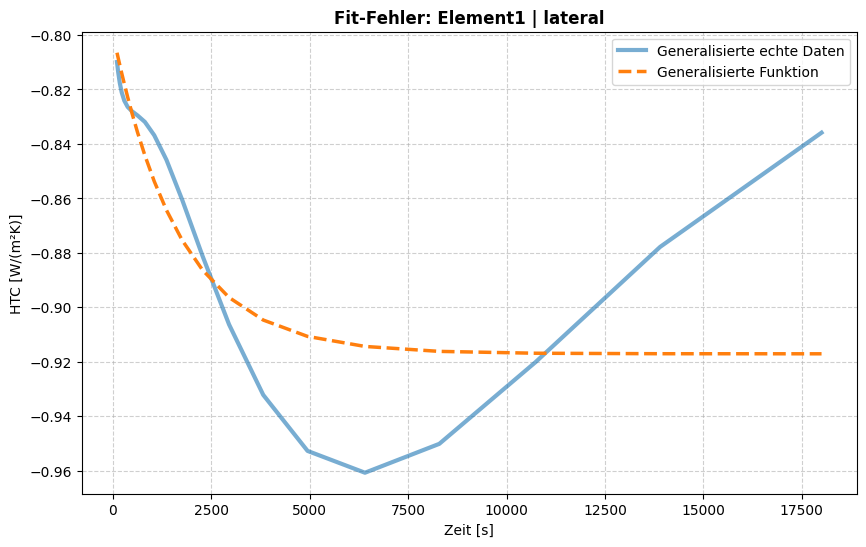

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Definition der Funktion (wie gehabt)
def doppel_exponential(t, a1, b1, a2, b2, c):
    return a1 * np.exp(-b1 * t) + a2 * np.exp(-b2 * t) + c

# Funktion zur Berechnung der Fehler (angepasst)
def berechne_fit_fehler(df_htc, element_name, region_name, cases, start_schaetzung, time_min=100):
    # Daten filtern
    df_fit = df_htc[
        (df_htc["element"] == element_name) &
        (df_htc["case"].isin(cases)) &
        (df_htc["region_group"] == region_name) &
        (df_htc["time_s"] >= time_min)
    ].copy()
    df_fit = df_fit.dropna(subset=["htc_agg"])

    # Generalisierte echte Daten (Mittelwert über Cases)
    df_generalized = df_fit.groupby("time_s")["htc_agg"].mean().reset_index()
    t_data = df_generalized["time_s"].values
    h_true_generalized = df_generalized["htc_agg"].values

    # Curve Fitting
    opt_params, _ = curve_fit(doppel_exponential, t_data, h_true_generalized,
                              p0=start_schaetzung, maxfev=10000)
    a1, b1, a2, b2, c = opt_params

    # Vorhersage der generalisierten Funktion
    h_pred_generalized = doppel_exponential(t_data, *opt_params)

    # Fehler der generalisierten Funktion
    mse = mean_squared_error(h_true_generalized, h_pred_generalized)
    mae = mean_absolute_error(h_true_generalized, h_pred_generalized)
    rmse = np.sqrt(mse)

    print("="*80)
    print(f"FEHLER DER GENERALISIERTEN FUNKTION")
    print(f"{element_name} | {region_name} | Cases: {cases}")
    print("="*80)
    print(f"MSE  = {mse:.6f}")
    print(f"MAE  = {mae:.6f}")
    print(f"RMSE = {rmse:.6f}")
    print("-"*80)
    print(f"h(t) = {a1:.6f} * e^(-{b1:.8f} * t) {a2:+.6f} * e^(-{b2:.8f} * t) {c:+.6f}")
    print("="*80)

    # Fehler pro einzelnem Case
    df_fit["h_pred"] = doppel_exponential(df_fit["time_s"].values, *opt_params)
    df_fit["absolute_error"] = np.abs(df_fit["htc_agg"] - df_fit["h_pred"])
    df_fit["squared_error"] = (df_fit["htc_agg"] - df_fit["h_pred"])**2

    fehler_pro_case = (
        df_fit.groupby("case")
        .agg(
            MSE=("squared_error", "mean"),
            MAE=("absolute_error", "mean"),
            RMSE=("squared_error", lambda x: np.sqrt(np.mean(x))),
            Anzahl_Werte=("htc_agg", "count")
        )
        .reset_index()
    )
    print("\nFEHLER PRO EINZELNEM CASE:")
    print(fehler_pro_case)

    # Optional: Plot
    plt.figure(figsize=(10,6))
    plt.plot(t_data, h_true_generalized, label="Generalisierte echte Daten", linewidth=3, alpha=0.6)
    plt.plot(t_data, h_pred_generalized, label="Generalisierte Funktion", linestyle="--", linewidth=2.5)
    plt.title(f"Fit-Fehler: {element_name} | {region_name}", fontweight="bold")
    plt.xlabel("Zeit [s]")
    plt.ylabel("HTC [W/(m²K)]")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

    return opt_params, fehler_pro_case

# Beispielaufruf für die laterale Fläche im Cooldown
opt_params, fehler_tabelle = berechne_fit_fehler(
    df_htc=df_htc,
    element_name="Element1",
    region_name="lateral",
    cases=("Case2", "Case4"),
    start_schaetzung=[0.05, 0.01, 0.03, 0.0001, -0.83],
    time_min=100
)

In [10]:
# ============================================================
# Heat-up und Cooldown separat definieren
# ============================================================

heatup_cases = ["Case1", "Case3", "Case5", "Case6", "Case7"]
cooldown_cases = ["Case2", "Case4"]

df_htc = df_htc.copy()

df_htc["phase"] = np.select(
    [
        df_htc["case"].isin(heatup_cases),
        df_htc["case"].isin(cooldown_cases)
    ],
    [
        "heatup",
        "cooldown"
    ],
    default="unknown"
)

display(df_htc[["case", "phase"]].drop_duplicates().sort_values("case"))

,case,phase
0,Case1,heatup
360,Case2,cooldown
720,Case3,heatup
1080,Case4,cooldown
1440,Case5,heatup
1800,Case6,heatup
2160,Case7,heatup


In [11]:
# ============================================================
# Generalisierte HTC-Kurven separat für Heat-up und Cooldown
# ============================================================

df_htc_clean = df_htc.dropna(subset=["htc_agg"]).copy()

df_generalized_phase = (
    df_htc_clean
    .groupby(["phase", "element", "region_group", "time_s"], as_index=False)
    .agg(
        htc_mean=("htc_agg", "mean"),
        htc_std=("htc_agg", "std"),
        htc_min=("htc_agg", "min"),
        htc_max=("htc_agg", "max"),
        n_cases=("case", "nunique")
    )
)

display(df_generalized_phase.head())

,phase,element,region_group,time_s,htc_mean,htc_std,htc_min,htc_max,n_cases
0,cooldown,Element1,bottom_surface,10.0,-0.207275,0.025462,-0.225279,-0.189271,2
1,cooldown,Element1,bottom_surface,13.0,-0.207568,0.025457,-0.225569,-0.189567,2
2,cooldown,Element1,bottom_surface,17.0,-0.208162,0.025434,-0.226147,-0.190178,2
3,cooldown,Element1,bottom_surface,22.0,-0.209096,0.025379,-0.227042,-0.191150,2
4,cooldown,Element1,bottom_surface,28.0,-0.210380,0.025280,-0.228256,-0.192504,2


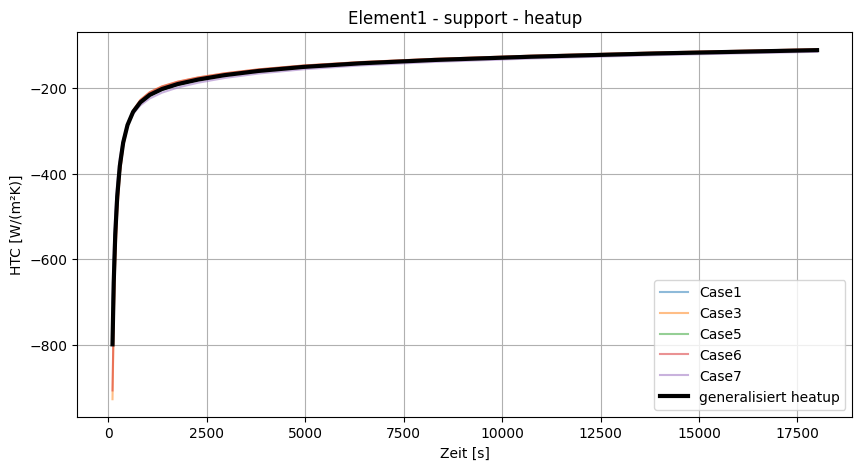

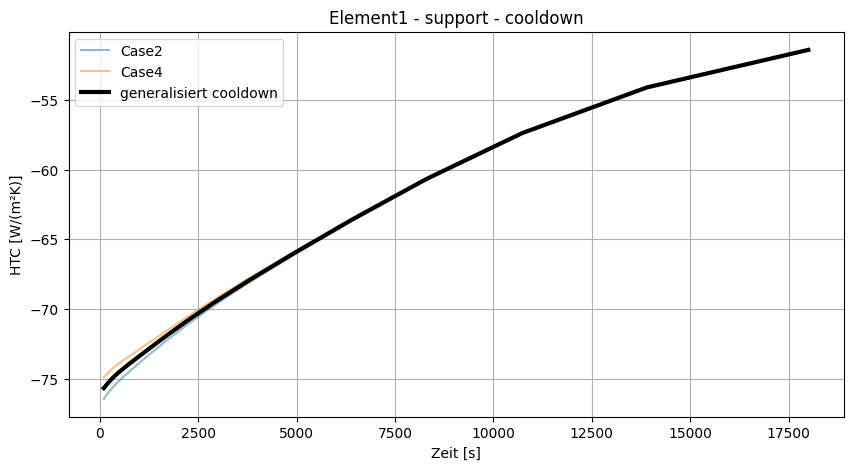

In [13]:
# ============================================================
# Plot: Heat-up und Cooldown getrennt vergleichen
# ============================================================

import matplotlib.pyplot as plt

def plot_phase_vergleich(df_htc, df_generalized_phase, element_name, region_name, time_min=100):
    
    df_plot = df_htc[
        (df_htc["element"] == element_name) &
        (df_htc["region_group"] == region_name) &
        (df_htc["time_s"] >= time_min)
    ].dropna(subset=["htc_agg"]).copy()
    
    for phase_name in ["heatup", "cooldown"]:
        plt.figure(figsize=(10, 5))
        
        df_phase = df_plot[df_plot["phase"] == phase_name]
        
        for case_name in sorted(df_phase["case"].unique()):
            df_case = df_phase[df_phase["case"] == case_name].sort_values("time_s")
            plt.plot(
                df_case["time_s"],
                df_case["htc_agg"],
                alpha=0.5,
                label=case_name
            )
        
        df_gen = df_generalized_phase[
            (df_generalized_phase["phase"] == phase_name) &
            (df_generalized_phase["element"] == element_name) &
            (df_generalized_phase["region_group"] == region_name) &
            (df_generalized_phase["time_s"] >= time_min)
        ].sort_values("time_s")
        
        plt.plot(
            df_gen["time_s"],
            df_gen["htc_mean"],
            linewidth=3,
            color="black",
            label=f"generalisiert {phase_name}"
        )
        
        plt.title(f"{element_name} - {region_name} - {phase_name}")
        plt.xlabel("Zeit [s]")
        plt.ylabel("HTC [W/(m²K)]")
        plt.grid(True)
        plt.legend()
        plt.show()


plot_phase_vergleich(
    df_htc,
    df_generalized_phase,
    element_name="Element1",
    region_name="support",
    time_min=100
)

In [14]:
# ============================================================
# Fehler je Case gegen die passende generalisierte Phase
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def berechne_case_fehler_gegen_phase_mean(df_htc, df_generalized_phase, time_min=100):
    
    results = []
    
    df_eval = df_htc[
        (df_htc["time_s"] >= time_min)
    ].dropna(subset=["htc_agg"]).copy()
    
    for (phase, element, region, case), df_case in df_eval.groupby(
        ["phase", "element", "region_group", "case"]
    ):
        if phase == "unknown":
            continue
        
        df_gen = df_generalized_phase[
            (df_generalized_phase["phase"] == phase) &
            (df_generalized_phase["element"] == element) &
            (df_generalized_phase["region_group"] == region)
        ][["time_s", "htc_mean"]]
        
        df_merged = df_case.merge(df_gen, on="time_s", how="inner")
        
        if len(df_merged) < 3:
            continue
        
        y_true = df_merged["htc_agg"]
        y_pred = df_merged["htc_mean"]
        
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        
        # relativer Fehler bezogen auf mittlere absolute HTC-Größe
        rel_mae = mae / np.mean(np.abs(y_true)) * 100
        
        results.append({
            "phase": phase,
            "element": element,
            "region_group": region,
            "case": case,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "rel_MAE_%": rel_mae,
            "n_points": len(df_merged)
        })
    
    return pd.DataFrame(results)

df_fehler_phase = berechne_case_fehler_gegen_phase_mean(
    df_htc,
    df_generalized_phase,
    time_min=100
)

display(df_fehler_phase.sort_values(["phase", "element", "region_group", "case"]))

,phase,element,region_group,case,MAE,MSE,RMSE,rel_MAE_%,n_points
0,cooldown,Element1,bottom_surface,Case2,0.007536,0.000096,0.009773,2.105439,21
1,cooldown,Element1,bottom_surface,Case4,0.007536,0.000096,0.009773,2.197994,21
2,cooldown,Element1,lateral,Case2,0.017293,0.000412,0.020297,1.991679,21
3,cooldown,Element1,lateral,Case4,0.017293,0.000412,0.020297,2.007426,21
4,cooldown,Element1,support,Case2,0.402022,0.234434,0.484183,0.577489,21
...,...,...,...,...,...,...,...,...,...
79,heatup,Element3,top_surface,Case1,0.014504,0.000260,0.016136,0.851098,21
80,heatup,Element3,top_surface,Case3,0.060464,0.004703,0.068580,3.707789,21
81,heatup,Element3,top_surface,Case5,0.014504,0.000260,0.016136,0.851099,21
82,heatup,Element3,top_surface,Case6,0.054143,0.003769,0.061392,3.307032,21


Die Heat-up-Fälle zeigen innerhalb derselben Oberflächenregion ähnliche HTC-Verläufe. Daher kann für Heat-up eine generalisierte zeitabhängige HTC-Funktion verwendet werden.  
Cooldown besitzt ein anderes thermisches Verhalten und wird deshalb separat modelliert.

In [15]:
# ============================================================
# Bewertung: Wo ist die Generalisierung gut / kritisch / schlecht?
# ============================================================

def bewerte_rel_fehler(rel_mae):
    if rel_mae < 5:
        return "sehr gut"
    elif rel_mae < 15:
        return "brauchbar"
    elif rel_mae < 30:
        return "kritisch"
    else:
        return "nicht gut"

df_generalization_summary = (
    df_fehler_phase
    .groupby(["phase", "element", "region_group"], as_index=False)
    .agg(
        MAE_mean=("MAE", "mean"),
        RMSE_mean=("RMSE", "mean"),
        rel_MAE_mean=("rel_MAE_%", "mean"),
        rel_MAE_max=("rel_MAE_%", "max"),
        n_cases=("case", "nunique")
    )
)

df_generalization_summary["bewertung"] = df_generalization_summary["rel_MAE_mean"].apply(bewerte_rel_fehler)

display(
    df_generalization_summary
    .sort_values(["phase", "element", "rel_MAE_mean"])
)

,phase,element,region_group,MAE_mean,RMSE_mean,rel_MAE_mean,rel_MAE_max,n_cases,bewertung
2,cooldown,Element1,support,0.402022,0.484183,0.580863,0.584236,2,sehr gut
1,cooldown,Element1,lateral,0.017293,0.020297,1.999552,2.007426,2,sehr gut
0,cooldown,Element1,bottom_surface,0.007536,0.009773,2.151717,2.197994,2,sehr gut
3,cooldown,Element1,top_surface,0.043256,0.049061,6.529930,6.924295,2,brauchbar
7,cooldown,Element2,top_surface,0.033569,0.038552,1.119500,1.119664,2,sehr gut
6,cooldown,Element2,support,1.164956,1.350973,1.511366,1.517587,2,sehr gut
5,cooldown,Element2,lateral,0.034823,0.040282,1.733125,1.733806,2,sehr gut
4,cooldown,Element2,bottom_surface,0.017913,0.020663,4.700050,4.780673,2,sehr gut
10,cooldown,Element3,support,1.724684,2.287054,9.782783,10.730824,2,brauchbar
9,cooldown,Element3,lateral,0.504125,0.672053,10.355648,11.416782,2,brauchbar


In [16]:
# ============================================================
# Automatisches Curve Fitting für alle Phasen / Elemente / Regionen
# ============================================================

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from sklearn.metrics import mean_absolute_error, mean_squared_error

def doppel_exponential(t, a1, b1, a2, b2, c):
    return a1 * np.exp(-b1 * t) + a2 * np.exp(-b2 * t) + c

def fit_phase_curve(df_generalized_phase, time_min=100):
    results = []
    
    df_fit_all = df_generalized_phase[
        (df_generalized_phase["time_s"] >= time_min) &
        (df_generalized_phase["phase"] != "unknown")
    ].dropna(subset=["htc_mean"]).copy()
    
    for (phase, element, region), df_group in df_fit_all.groupby(["phase", "element", "region_group"]):
        
        df_group = df_group.sort_values("time_s").copy()
        
        t = df_group["time_s"].values
        y = df_group["htc_mean"].values
        
        if len(t) < 5:
            continue
        
        y_start = y[0]
        y_end = y[-1]
        delta = y_start - y_end
        
        # robuste Startschätzung
        p0 = [
            0.7 * delta,
            0.001,
            0.3 * delta,
            0.0001,
            y_end
        ]
        
        try:
            params, _ = curve_fit(
                doppel_exponential,
                t,
                y,
                p0=p0,
                bounds=(
                    [-np.inf, 0, -np.inf, 0, -np.inf],
                    [ np.inf, 1,  np.inf, 1,  np.inf]
                ),
                maxfev=50000
            )
            
            y_pred = doppel_exponential(t, *params)
            
            mae = mean_absolute_error(y, y_pred)
            mse = mean_squared_error(y, y_pred)
            rmse = np.sqrt(mse)
            rel_mae = mae / np.mean(np.abs(y)) * 100
            
            a1, b1, a2, b2, c = params
            
            results.append({
                "phase": phase,
                "element": element,
                "region_group": region,
                "a1": a1,
                "b1": b1,
                "a2": a2,
                "b2": b2,
                "c": c,
                "MAE_fit": mae,
                "MSE_fit": mse,
                "RMSE_fit": rmse,
                "rel_MAE_fit_%": rel_mae,
                "n_points": len(t),
                "fit_status": "ok"
            })
            
        except Exception as e:
            results.append({
                "phase": phase,
                "element": element,
                "region_group": region,
                "a1": np.nan,
                "b1": np.nan,
                "a2": np.nan,
                "b2": np.nan,
                "c": np.nan,
                "MAE_fit": np.nan,
                "MSE_fit": np.nan,
                "RMSE_fit": np.nan,
                "rel_MAE_fit_%": np.nan,
                "n_points": len(t),
                "fit_status": f"failed: {e}"
            })
    
    return pd.DataFrame(results)

df_fit_results = fit_phase_curve(df_generalized_phase, time_min=100)

display(
    df_fit_results
    .sort_values(["phase", "element", "region_group"])
)

,phase,element,region_group,a1,b1,a2,b2,c,MAE_fit,MSE_fit,RMSE_fit,rel_MAE_fit_%,n_points,fit_status
0,cooldown,Element1,bottom_surface,0.206383,0.001379,0.019628,1.379169e-03,-0.418236,0.012951,0.000356,0.018859,3.696370,21,ok
1,cooldown,Element1,lateral,3.046375,0.001152,-2.951150,1.205331e-03,-0.918299,0.016162,0.000655,0.025584,1.868720,21,ok
2,cooldown,Element1,support,926.499869,0.000121,-957.548541,1.196943e-04,-44.671749,0.113730,0.016164,0.127138,0.164317,21,ok
3,cooldown,Element1,top_surface,0.521054,0.000308,0.868174,3.078433e-04,-0.152251,0.007097,0.000067,0.008215,1.067513,21,ok
4,cooldown,Element2,bottom_surface,105.269166,0.000431,-106.000297,4.282186e-04,0.124745,0.002266,0.000008,0.002787,0.594258,21,ok
5,cooldown,Element2,lateral,0.630557,0.000856,-2.535240,2.314173e-04,-0.701019,0.001414,0.000003,0.001697,0.070388,21,ok
6,cooldown,Element2,support,15.669942,0.001033,-90.719976,2.293494e-04,-27.004059,0.042435,0.002454,0.049535,0.055052,21,ok
7,cooldown,Element2,top_surface,1.047045,0.000769,-3.941453,2.142456e-04,-0.954955,0.004779,0.000028,0.005279,0.159361,21,ok
8,cooldown,Element3,bottom_surface,2.479973,0.000735,1.784214,1.909797e-04,0.226549,0.034956,0.002041,0.045176,1.466340,21,ok
9,cooldown,Element3,lateral,-16.102701,0.005015,-4.172107,4.717173e-04,-1.055114,0.064100,0.005194,0.072072,1.302900,21,ok


In [17]:
# ============================================================
# Finale Ergebnistabelle: Generalisierbarkeit + Fit-Qualität
# ============================================================

df_final_results = df_generalization_summary.merge(
    df_fit_results,
    on=["phase", "element", "region_group"],
    how="left"
)

df_final_results["fit_bewertung"] = df_final_results["rel_MAE_fit_%"].apply(
    lambda x: "sehr gut" if x < 5 else
              "brauchbar" if x < 15 else
              "kritisch" if x < 30 else
              "nicht gut"
)

display(
    df_final_results
    .sort_values(["phase", "element", "rel_MAE_mean"])
)

,phase,element,region_group,MAE_mean,RMSE_mean,rel_MAE_mean,rel_MAE_max,n_cases,bewertung,a1,...,a2,b2,c,MAE_fit,MSE_fit,RMSE_fit,rel_MAE_fit_%,n_points,fit_status,fit_bewertung
2,cooldown,Element1,support,0.402022,0.484183,0.580863,0.584236,2,sehr gut,926.499869,...,-957.548541,1.196943e-04,-44.671749,0.113730,0.016164,0.127138,0.164317,21,ok,sehr gut
1,cooldown,Element1,lateral,0.017293,0.020297,1.999552,2.007426,2,sehr gut,3.046375,...,-2.951150,1.205331e-03,-0.918299,0.016162,0.000655,0.025584,1.868720,21,ok,sehr gut
0,cooldown,Element1,bottom_surface,0.007536,0.009773,2.151717,2.197994,2,sehr gut,0.206383,...,0.019628,1.379169e-03,-0.418236,0.012951,0.000356,0.018859,3.696370,21,ok,sehr gut
3,cooldown,Element1,top_surface,0.043256,0.049061,6.529930,6.924295,2,brauchbar,0.521054,...,0.868174,3.078433e-04,-0.152251,0.007097,0.000067,0.008215,1.067513,21,ok,sehr gut
7,cooldown,Element2,top_surface,0.033569,0.038552,1.119500,1.119664,2,sehr gut,1.047045,...,-3.941453,2.142456e-04,-0.954955,0.004779,0.000028,0.005279,0.159361,21,ok,sehr gut
6,cooldown,Element2,support,1.164956,1.350973,1.511366,1.517587,2,sehr gut,15.669942,...,-90.719976,2.293494e-04,-27.004059,0.042435,0.002454,0.049535,0.055052,21,ok,sehr gut
5,cooldown,Element2,lateral,0.034823,0.040282,1.733125,1.733806,2,sehr gut,0.630557,...,-2.535240,2.314173e-04,-0.701019,0.001414,0.000003,0.001697,0.070388,21,ok,sehr gut
4,cooldown,Element2,bottom_surface,0.017913,0.020663,4.700050,4.780673,2,sehr gut,105.269166,...,-106.000297,4.282186e-04,0.124745,0.002266,0.000008,0.002787,0.594258,21,ok,sehr gut
10,cooldown,Element3,support,1.724684,2.287054,9.782783,10.730824,2,brauchbar,-64.423993,...,-14.386242,5.019369e-04,-3.815161,0.235185,0.069015,0.262707,1.321492,21,ok,sehr gut
9,cooldown,Element3,lateral,0.504125,0.672053,10.355648,11.416782,2,brauchbar,-16.102701,...,-4.172107,4.717173e-04,-1.055114,0.064100,0.005194,0.072072,1.302900,21,ok,sehr gut
